In [1]:
import pandas as pd
from pathlib import Path
import sys
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import zscore

In [ ]:
# Check if there a column with the wrong type


PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw"
df_train = pd.read_csv(DATA_PATH / "train.csv")

df_train.dtypes.to_frame("dtype")

,dtype
Id,int64
MSSubClass,int64
MSZoning,object
LotFrontage,float64
LotArea,int64
...,...
MoSold,int64
YrSold,int64
SaleType,object
SaleCondition,object


In [3]:
# Months and year shouldn't be int but object

df_train["MoSold"] = df_train["MoSold"].astype(object)
df_train["YrSold"] = df_train["YrSold"].astype(object)
df_train["GarageYrBlt"] = df_train["GarageYrBlt"].astype(object)
df_train["MSSubClass"] = df_train["MSSubClass"].astype(str)

In [4]:
# Check if there is any column with missing values

df_train.isna().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [5]:
# The result is that the Alley and LotFrontage have missing values, for Alley there is no input to do because
# Alley is an object, for LotFrontage it will be replaced with the median of the neighborhood.

df_train["LotFrontage"] = df_train.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

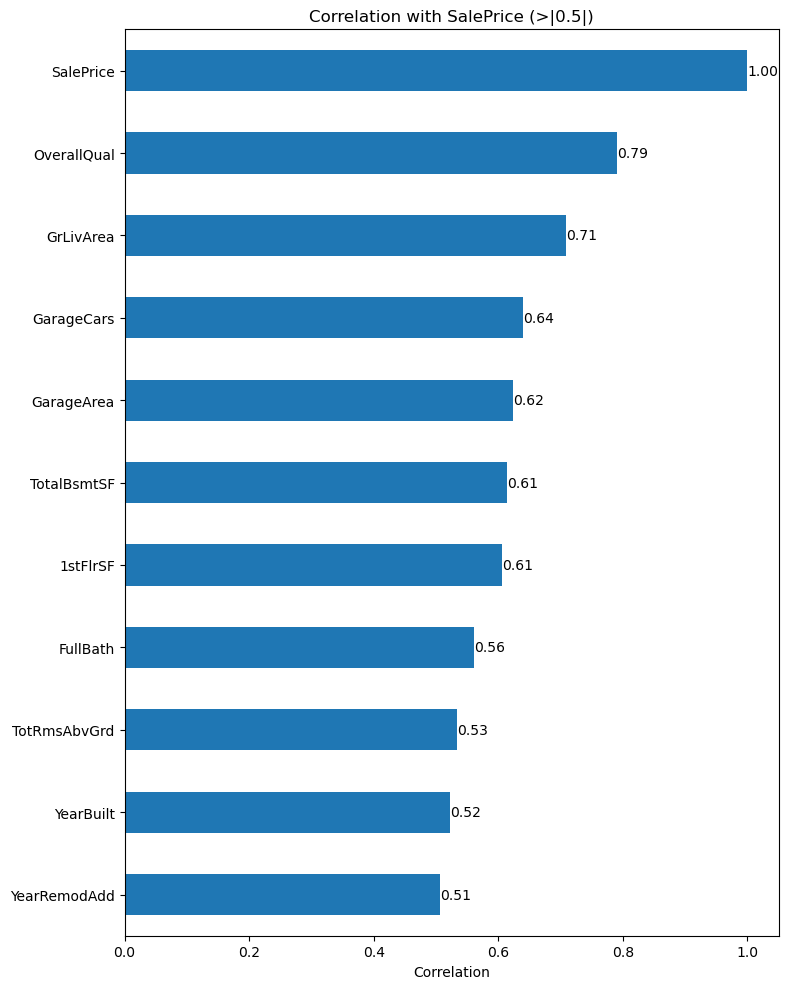

In [6]:
# A table that shows all int and float to do the correlation

table_types = df_train.dtypes[df_train.dtypes != 'object'].reset_index()
table_types

train_corr = df_train[[
    'Id','MSSubClass','LotFrontage','LotArea','OverallQual','OverallCond','YearBuilt','YearRemodAdd',
    'MasVnrArea','BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF','1stFlrSF','2ndFlrSF','LowQualFinSF',
    'GrLivArea','BsmtFullBath','BsmtHalfBath','FullBath','HalfBath','BedroomAbvGr','KitchenAbvGr',
    'TotRmsAbvGrd','Fireplaces','GarageYrBlt','GarageCars','GarageArea','WoodDeckSF','OpenPorchSF',
    'EnclosedPorch','3SsnPorch','ScreenPorch','PoolArea','MiscVal','MoSold','YrSold','SalePrice'
]]

# Correlation matrix just with Sale Price

corr = train_corr.corr()

# greater than 0.5
corr_filtered = corr["SalePrice"][corr["SalePrice"].abs() > 0.5]

plt.figure(figsize=(8, 10))
corr_sorted = corr_filtered.sort_values()

ax = corr_sorted.plot(kind='barh')

# adicionar valores ao lado das barras
for i, v in enumerate(corr_sorted):
    ax.text(v, i, f"{v:.2f}", va='center', fontsize=10)

plt.title("Correlation with SalePrice (>|0.5|)")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()


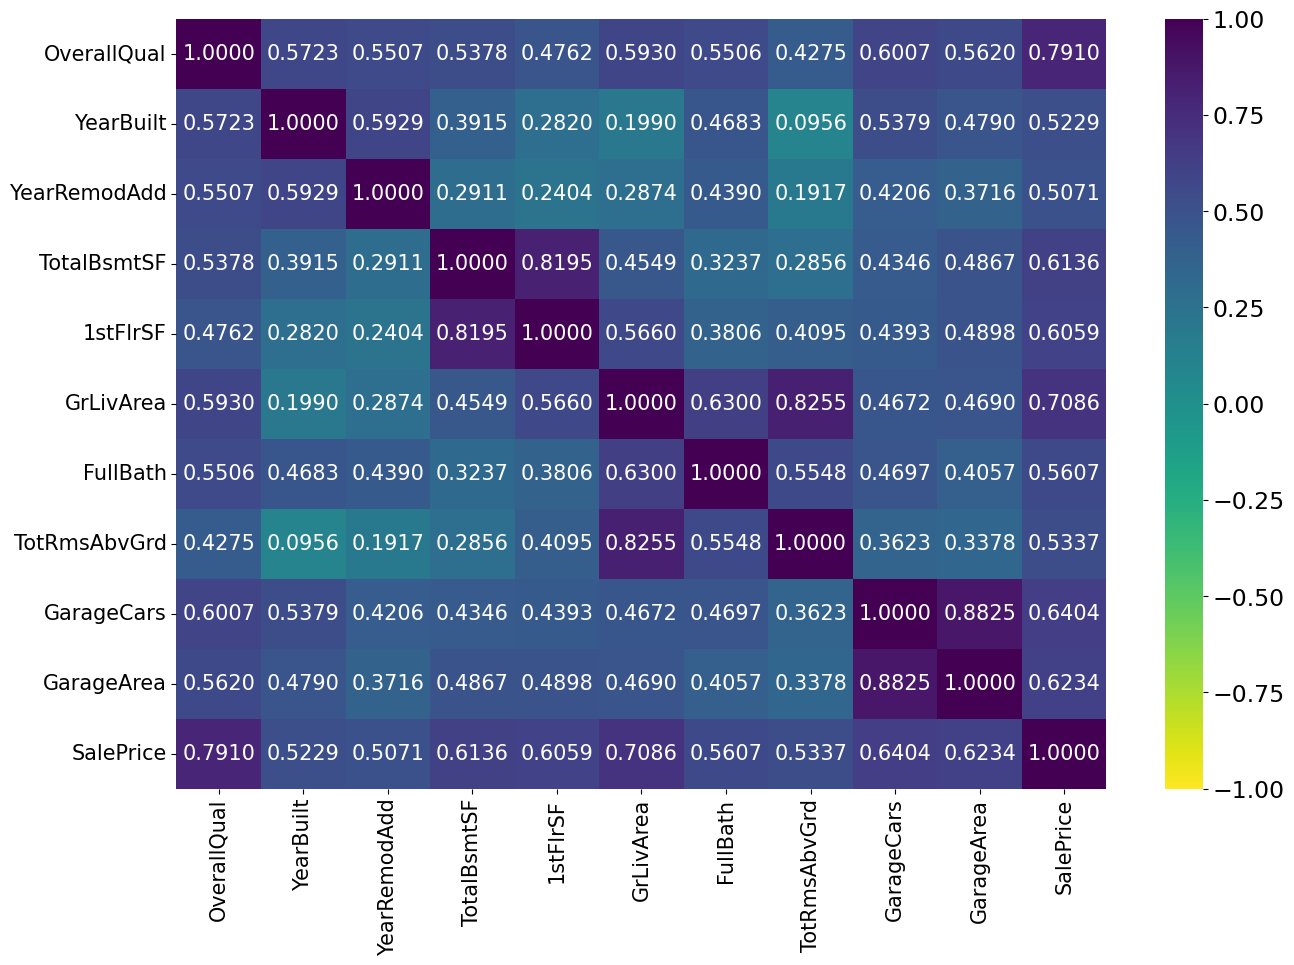

In [7]:
train_corr_2 = df_train[[
    'OverallQual','YearBuilt','YearRemodAdd','TotalBsmtSF','1stFlrSF','GrLivArea','FullBath','TotRmsAbvGrd','GarageCars','GarageArea','SalePrice'
]]

# Correlation matrix just with Sale Price

corr_2 = train_corr_2.corr()

plt.figure(figsize=(15, 10))
heatmap = sns.heatmap(corr_2, annot=True, fmt=".4f",
                      cmap=plt.cm.viridis_r,
                      annot_kws={'size': 15}, vmin=-1, vmax=1)
heatmap.set_xticklabels(heatmap.get_xticklabels(), fontsize=15)
heatmap.set_yticklabels(heatmap.get_yticklabels(), fontsize=15)
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=17)
plt.show()

In [8]:
# Split in numeric data frame

num_cols = df_train.select_dtypes(include=['int64', 'float64']).columns

In [9]:
# These 3 columns deleted from the data frame

num_cols_tot = num_cols.drop(['1stFlrSF','GrLivArea','GarageCars'])
num_cols_tot = num_cols_tot.drop('SalePrice', errors='ignore')
df_model_tot = df_train[list(num_cols_tot) + ['SalePrice']]

In [10]:
# 1st model OLS

model = sm.OLS.from_formula("SalePrice ~ GarageArea + OverallQual + YearBuilt + YearRemodAdd + TotalBsmtSF + FullBath + TotRmsAbvGrd", df_model_tot).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.745
Model:                            OLS   Adj. R-squared:                  0.744
Method:                 Least Squares   F-statistic:                     605.7
Date:                Wed, 01 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:12:38   Log-Likelihood:                -17547.
No. Observations:                1460   AIC:                         3.511e+04
Df Residuals:                    1452   BIC:                         3.515e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept    -9.639e+05   1.34e+05     -7.207      0.000   -1.23e+06   -7.02e+05
GarageArea      57.3812      6.404      8.960      0.000      44.819      69.943
OverallQual   2.405e+04   1192.455     20.166      0.000    2.17e+04    2.64e+04
YearBuilt      135.0126     51.151      2.639      0.008      34.675     235.350
YearRemodAdd   298.8173     67.480      4.428      0.000     166.449     431.186
TotalBsmtSF     36.5240      2.971     12.293      0.000      30.696      42.352
FullBath      3989.2346   2716.869      1.468      0.142   -1340.174    9318.643
TotRmsAbvGrd  1.026e+04    853.213     12.022      0.000    8583.614    1.19e+04
==============================================================================
Omnibus:                      526.212   Durbin-Watson:                   1.962
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            26465.490
Skew:                           0.896   Prob(JB):                         0.00
Kurtosis:                      23.781   Cond. No.                     3.85e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.85e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [11]:
# 2nd model removing FullBath because the pvalue is greater than 0.05

model = sm.OLS.from_formula("SalePrice ~ GarageArea + OverallQual + YearBuilt + YearRemodAdd + TotalBsmtSF + TotRmsAbvGrd", df_model_tot).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.745
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     705.7
Date:                Wed, 01 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:12:38   Log-Likelihood:                -17548.
No. Observations:                1460   AIC:                         3.511e+04
Df Residuals:                    1453   BIC:                         3.515e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept    -1.027e+06   1.27e+05     -8.099      0.000   -1.28e+06   -7.78e+05
GarageArea      57.4823      6.406      8.973      0.000      44.916      70.049
OverallQual   2.428e+04   1182.199     20.539      0.000     2.2e+04    2.66e+04
YearBuilt      155.6831     49.195      3.165      0.002      59.182     252.184
YearRemodAdd   310.3990     67.044      4.630      0.000     178.885     441.912
TotalBsmtSF     36.3658      2.970     12.243      0.000      30.539      42.192
TotRmsAbvGrd  1.086e+04    746.409     14.556      0.000    9400.814    1.23e+04
==============================================================================
Omnibus:                      531.256   Durbin-Watson:                   1.965
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            27377.297
Skew:                           0.905   Prob(JB):                         0.00
Kurtosis:                      24.137   Cond. No.                     3.65e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.65e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [12]:
# Due to the huge number in the condition (3.65e+05), I am checking multicollinearity
# The result is: there is no evidence of multicollinearity 

X1 = sm.add_constant(df_model_tot[['GarageArea', 'OverallQual', 'YearBuilt', 'YearRemodAdd', 'TotalBsmtSF', 'TotRmsAbvGrd']])
VIF = pd.DataFrame()
VIF["VIF"] = [variance_inflation_factor(X1.values, i+1)
              for i in range(X1.shape[1]-1)]
VIF["Tolerância"] = 1 / VIF["VIF"]
VIF

,VIF,Tolerância
0,1.690632,0.591495
1,2.409004,0.415109
2,1.989556,0.502625
3,1.726558,0.579187
4,1.530275,0.653477
5,1.326431,0.753903


In [13]:
# Suggested by copilot to change to standard normal distribution
# Result is: the condition number is no low.

df_model_tot_pad = df_model_tot.apply(zscore, ddof=1)

model_pad = sm.OLS.from_formula("SalePrice ~ GarageArea + OverallQual + YearBuilt + YearRemodAdd + TotalBsmtSF + TotRmsAbvGrd", df_model_tot_pad).fit()
model_pad.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.745
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     705.7
Date:                Wed, 01 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:12:38   Log-Likelihood:                -1075.0
No. Observations:                1460   AIC:                             2164.
Df Residuals:                    1453   BIC:                             2201.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     1.288e-16      0.013   9.72e-15      1.000      -0.026       0.026
GarageArea       0.1547      0.017      8.973      0.000       0.121       0.189
OverallQual      0.4227      0.021     20.539      0.000       0.382       0.463
YearBuilt        0.0592      0.019      3.165      0.002       0.023       0.096
YearRemodAdd     0.0807      0.017      4.630      0.000       0.046       0.115
TotalBsmtSF      0.2008      0.016     12.243      0.000       0.169       0.233
TotRmsAbvGrd     0.2223      0.015     14.556      0.000       0.192       0.252
==============================================================================
Omnibus:                      531.256   Durbin-Watson:                   1.965
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            27377.297
Skew:                           0.905   Prob(JB):                         0.00
Kurtosis:                      24.137   Cond. No.                         3.14
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# Transforming the test columns in standard normal distribution using the mean and the standard distribution from train model.
# Predicting the Sale Price using the model from the train and changed back to get 'real' numbers of Sale Price.

X_cols = ['GarageArea', 'OverallQual', 'YearBuilt',
          'YearRemodAdd', 'TotalBsmtSF', 'TotRmsAbvGrd']

means = df_train[X_cols].mean()
stds  = df_train[X_cols].std()

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw"
df_test  = pd.read_csv(DATA_PATH / "test.csv")

df_test_pad = (df_test[X_cols] - means) / stds

df_test_pad['SalePrice_pred'] = model_pad.predict(df_test_pad)

mean_y = df_train['SalePrice'].mean()
std_y  = df_train['SalePrice'].std()

df_test_pad['SalePrice_pred_real'] = (
    df_test_pad['SalePrice_pred'] * std_y + mean_y
)

print(df_test_pad)


      GarageArea  OverallQual  YearBuilt  YearRemodAdd  TotalBsmtSF  \
0       1.202124    -0.794879  -0.339961     -1.155984    -0.399880   
1      -0.752930    -0.071812  -0.439289     -1.301294     0.619027   
2       0.042187    -0.794879   0.851977      0.636183    -0.295026   
3      -0.013939    -0.071812   0.885087      0.636183    -0.299585   
4       0.154439     1.374324   0.686430      0.345561     0.507335   
...          ...          ...        ...           ...          ...   
1454   -2.212205    -1.517947  -0.041976     -0.720051    -1.165770   
1455   -0.874536    -1.517947  -0.041976     -0.720051    -1.165770   
1456    0.481841    -0.794879  -0.373070      0.539309     0.379687   
1457   -2.212205    -0.794879   0.686430      0.345561    -0.331497   
1458    0.827951     0.651256   0.719540      0.442435    -0.140024   

      TotRmsAbvGrd  SalePrice_pred  SalePrice_pred_real  
0        -0.933810       -0.551292        137125.157791  
1        -0.318574       -0.224